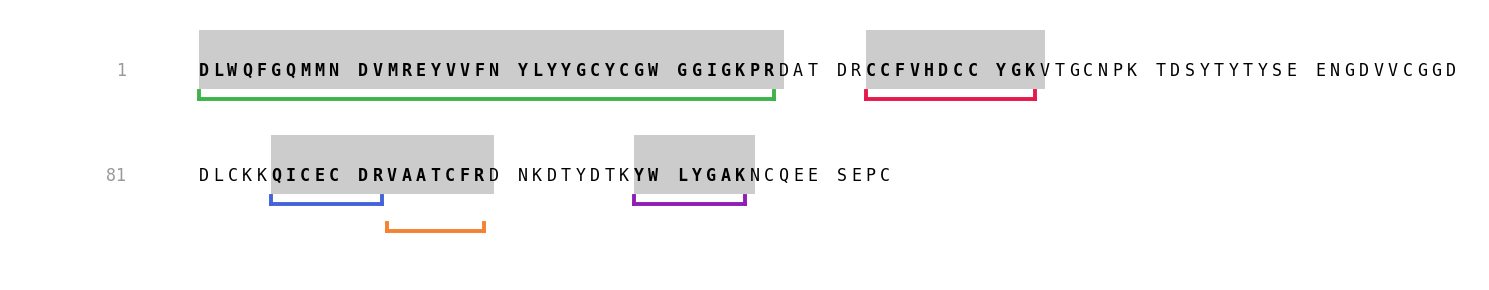

In [36]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import re

def plot_peptide_match(protein_seq, peptide_list):
    """
    Genera una imagen de la secuencia proteica resaltando múltiples péptidos.
    Aplica colores distintos a cada uno y ajusta el espaciado vertical de forma
    dinámica para evitar que los trazos se amontonen al solaparse.
    """
    chars_per_line = 80
    block_size = 10

    char_width = 0.15
    block_spacing = 0.15

    color_text = 'black'
    color_number = '#999999'
    color_highlight = '#cccccc'

    # 1. Paleta de colores vibrantes (Cambiarán automáticamente por cada péptido)
    color_palette = [
        '#e6194b', # Rojo vibrante
        '#3cb44b', # Verde fuerte
        '#4363d8', # Azul vibrante
        '#f58231', # Naranja
        '#911eb4', # Morado
        '#f032e6', # Magenta
        '#008080', # Verde azulado
        '#fabebe', # Rosa claro (contraste)
        '#800000', # Granate
        '#000075', # Azul marino
    ]

    # --- 2. Calcular niveles y ocurrencias para organizar los espacios ---
    row_levels = {}
    highlighted_indices = set()
    all_combined_spans = []

    for pept_idx, peptide_seq in enumerate(peptide_list):
        if not peptide_seq: continue
        # Asignar color de la paleta (repite si hay más péptidos que colores)
        color = color_palette[pept_idx % len(color_palette)]

        matches = [m.start() for m in re.finditer(f'(?=({peptide_seq}))', protein_seq)]
        match_spans = [(start, start + len(peptide_seq)) for start in matches]

        all_combined_spans.extend(match_spans)
        for start, end in match_spans:
            for i in range(start, end):
                highlighted_indices.add(i)

            # Planificar líneas por filas para evitar colisiones
            curr_start = start
            while curr_start < end:
                row_start = curr_start // chars_per_line
                curr_end = min(end, (row_start + 1) * chars_per_line)

                if row_start not in row_levels:
                    row_levels[row_start] = []

                level = 0
                while True:
                    conflict = False
                    for (s, e, l, _, _) in row_levels[row_start]:
                        if l == level:
                            if not (curr_end < s - 1 or curr_start > e + 1):
                                conflict = True
                                break
                    if not conflict:
                        break
                    level += 1

                row_levels[row_start].append((curr_start, curr_end, level, color, pept_idx))
                curr_start = curr_end

    # --- 3. Calcular Espaciado Vertical Dinámico (Nuevo) ---
    num_lines = (len(protein_seq) + chars_per_line - 1) // chars_per_line
    base_line_height = 1.2  # Altura base más holgada
    level_spacing = 0.40    # Espacio extra por cada nivel de trazo

    row_y_coords = {}
    current_y = 0

    for row in range(num_lines):
        row_y_coords[row] = current_y
        max_level = -1
        if row in row_levels:
            max_level = max(l for (_, _, l, _, _) in row_levels[row])

        # La siguiente fila baja dependiendo de cuántas líneas se dibujaron en esta
        current_y -= (base_line_height + max(0, max_level + 1) * level_spacing)

    # --- 4. Preparar el lienzo ---
    fig_height = max(3.0, abs(current_y) * 0.7)
    fig, ax = plt.subplots(figsize=(15, fig_height))
    ax.axis('off')

    def get_xy(index):
        row = index // chars_per_line
        col = index % chars_per_line
        x = col * char_width + (col // block_size) * block_spacing
        y = row_y_coords[row] # Usamos la coordenada Y dinámica calculada
        return x, y, row, col

    # --- 5. Dibujar fondo gris continuo ---
    all_combined_spans.sort()
    merged_spans = []
    if all_combined_spans:
        curr_start, curr_end = all_combined_spans[0]
        for start, end in all_combined_spans[1:]:
            if start <= curr_end: # Fusiona si se solapan o tocan
                curr_end = max(curr_end, end)
            else:
                merged_spans.append((curr_start, curr_end))
                curr_start, curr_end = start, end
        merged_spans.append((curr_start, curr_end))

    for start, end in merged_spans:
        curr_start = start
        while curr_start < end:
            row_start = curr_start // chars_per_line
            curr_end = min(end, (row_start + 1) * chars_per_line)
            x_start, y_start, _, _ = get_xy(curr_start)
            x_end, _, _, _ = get_xy(curr_end - 1)

            rect = patches.Rectangle(
                (x_start - 0.05, y_start - 0.2),
                (x_end - x_start + 0.2), 0.9,
                linewidth=0, facecolor=color_highlight, zorder=1
            )
            ax.add_patch(rect)
            curr_start = curr_end

    # --- 6. Escribir la secuencia ---
    for i, char in enumerate(protein_seq):
        x, y, row, col = get_xy(i)

        if col == 0:
            ax.text(x - 0.8, y, str(i + 1), fontfamily='monospace',
                    color=color_number, fontsize=12, ha='right', zorder=2)

        weight = 'bold' if i in highlighted_indices else 'normal'
        ax.text(x, y, char, fontfamily='monospace', color=color_text,
                fontsize=12, fontweight=weight, ha='center', zorder=3)

    # --- 7. Dibujar las líneas de colores apiladas ---
    for row, lines in row_levels.items():
        for (start_idx, end_idx, level, color, _) in lines:
            x_start, y_start, _, _ = get_xy(start_idx)
            x_end, _, _, _ = get_xy(end_idx - 1)

            y_line = y_start - 0.35 - (level * level_spacing)

            # Trazos con el color correspondiente
            ax.plot([x_start - 0.05, x_end + 0.05], [y_line, y_line], color=color, lw=2.8)
            ax.plot([x_start - 0.05, x_start - 0.05], [y_line, y_line + 0.12], color=color, lw=2.8)
            ax.plot([x_end + 0.05, x_end + 0.05], [y_line, y_line + 0.12], color=color, lw=2.8)

    ax.set_xlim(-2, chars_per_line * char_width + (chars_per_line // block_size) * block_spacing)
    ax.set_ylim(current_y + 0.5, 1) # Asegurar que la última fila quepa bien
    plt.tight_layout()
    plt.show()

# ==========================================
# EJEMPLO CON VARIOS PÉPTIDOS
# ==========================================

proteina = (
    "DLWQFGQMMNDVMREYVVFNYLYYGCYCGWGGIGKPRDATDRCCFVHDCCYGKVTGCNPKTDSYTYTYSEENGDVVCGGDDLCKKQICECDRVAATCFRDNKDTYDTKYWLYGAKNCQEESEPC"
)

# He agregado un tercer péptido ("LIRLDSR") para que veas el triple solapamiento,
# el cambio de colores y cómo el espaciado se abre automáticamente.
peptidos = ["CCFVHDCCYGK", "DLWQFGQMMNDVMREYVVFNYLYYGCYCGWGGIGKPR", "QICECDR", "VAATCFR", "YWLYGAK"]

plot_peptide_match(proteina, peptidos)